# Taller Cálculo de raices

**Nombre:** Joel Velez  **Fecha:** 12/06/2026   **Curso:** GR1CC

# Introducción 
+ Extensión de python: py
+ Extensión de notebook: .ipynb

Símbolo de la terminal
# Bash
```
$ cat
```


Command Prompt | Power Shell
```
> cd
```

Python
```
>>> print("Hola mundo")
````


## Ejercicio 1
Gráfica de precio vs tokens para el modelo GPT 5.5 y diferenciar en los casos de short context y long context.   
Dividir el problema en pasos
+ Necesito tokens, precio
+ tokens: lista de 0 a 1 millón

- Puntos de referencia: 
    Sabemos que USD 30 por cada millón de tokens
    $$\frac{30}{1000000} = 0.000030$$
    \
    Sabemos que USD 45 por cada millón de tokens
    $$\frac{45}{1000000} = 0.000045$$

    \
    Cost base límite:  
    No se puede pasar más de 272000 tokens para ser short context
    $$ 272000 * 0.000030 = 8.16$$


In [1]:
import numpy as np

In [2]:
# Crea la lista en memoria (0 a 1,000,000)
tokens = list(range(1000001))

In [3]:
limite = 272000
tarifa_short = 30/1_000_000
tarifa_long = 45/ 1_000_000

costo_base_limite = limite * tarifa_short

precios = []
for num in tokens:
    if num <= 272000:
        precios.append(num * tarifa_short)
    else:
        precios.append(costo_base_limite + (num - limite) * tarifa_long)

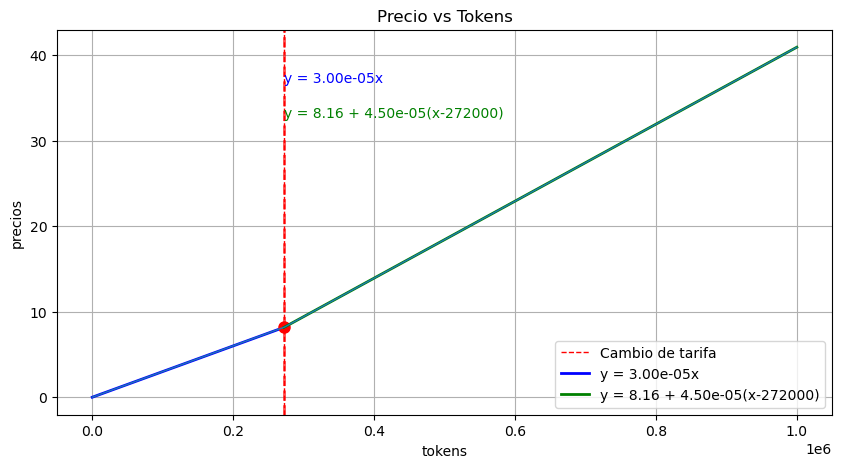

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.axvline(x=limite, color='red', linestyle='--', linewidth=1, label='Cambio de tarifa')
plt.text(limite, max(precios)*0.9, f'y = {tarifa_short:.2e}x', fontsize=10, color='blue')
plt.text(limite, max(precios)*0.8, f'y = {costo_base_limite:.2f} + {tarifa_long:.2e}(x-{limite})', fontsize=10, color='green')
plt.axvline(x=limite, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.plot(tokens[:limite+1], precios[:limite+1], linewidth=2, color='blue', label=f'y = {tarifa_short:.2e}x')
plt.plot([limite], [costo_base_limite], 'ro', markersize=8)
plt.plot(tokens[limite:], precios[limite:], linewidth=2, color='green', label=f'y = {costo_base_limite:.2f} + {tarifa_long:.2e}(x-{limite})')
plt.legend()
plt.plot(tokens, precios, linewidth=1)
plt.xlabel('tokens')
plt.ylabel('precios')
plt.title('Precio vs Tokens')
plt.grid(True)
plt.show()

### Ejercicio 2
Encontrar todas las raíces de la ecuación $f(x) = \frac{1}{4}(x^3 + 3x^2 - 6x - 8)$
usando el método de la bisección.  Grafique. Modifique el número de iteraciones a 5. Pruebe los siguientes rangos de búsqueda ([-5 3], [-4.7 2.5], [-4.5 2.7], [-3 -2]). 


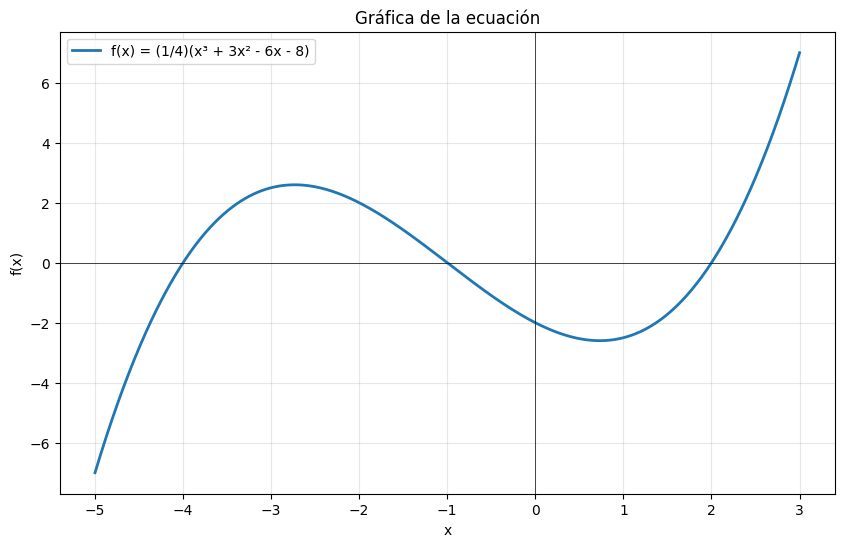

In [5]:
import numpy as np
def ecuacion(x):
    return (0.25)*(x**3 + 3*x**2 - 6*x - 8)

# Graficar la ecuación
x_valores = np.linspace(-5, 3, 1000)
y_valores = [ecuacion(x) for x in x_valores]

plt.figure(figsize=(10, 6))
plt.plot(x_valores, y_valores, linewidth=2, label='f(x) = (1/4)(x³ + 3x² - 6x - 8)')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gráfica de la ecuación')
plt.legend()
plt.show()



 Procedimiento completado exitosamente en 1 iteraciones.
 La raíz aproximada es: -1.0
 Procedimiento completado exitosamente en 17 iteraciones.
 La raíz aproximada es: -4.000006103515625
 Procedimiento completado exitosamente en 17 iteraciones.
 La raíz aproximada es: 2.0000061035156254
 Valor de f(a) es 2.5 y de f(b) es 2.0
 No se aceptan valores con el mismo signo


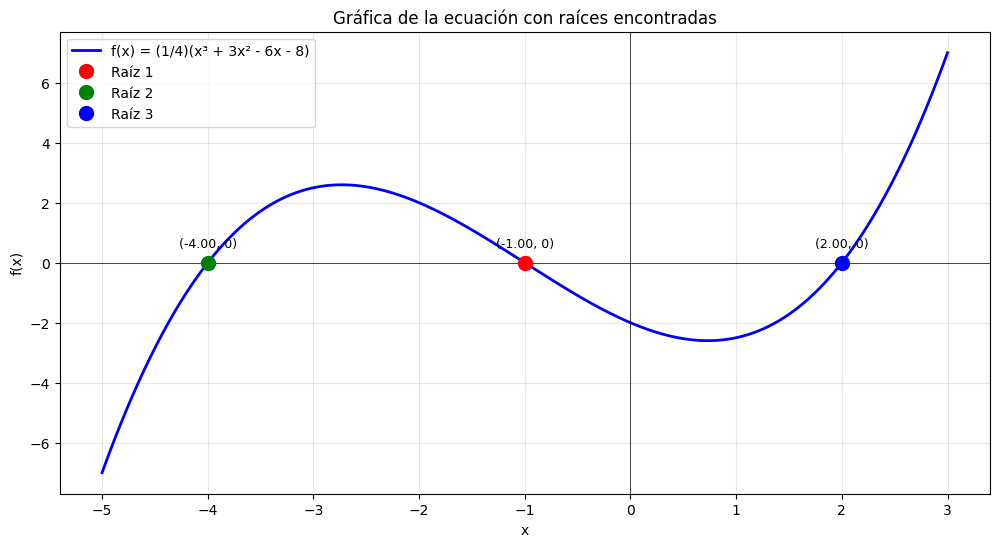

In [6]:
def ecuacion(x):
    return (0.25)*(x**3 + 3*x**2 - 6*x - 8)

def biseccion(f,a,b,TOL, N0):
    """ 
    f: la función
    a: límite inferior del intervalo
    b: limite superior del intervalo
    TOL: tolerancia
    N0: numero de interacciones
    """

    # validaciones iniciales
    if a >= b:
        print(" a debe ser mayor que b, rango inválido")
        return None
    
    if f(a) * f(b) >= 0:
        print(f" Valor de f(a) es {f(a)} y de f(b) es {f(b)}")
        print(" No se aceptan valores con el mismo signo")
        return None

    # Paso 1
    i = 1
    FA = f(a)

    while i <= N0:
        p = a +(b - a)/2
        FP = f(p)

        if FP == 0 or (b-a)/2 < TOL:
            print(f" Procedimiento completado exitosamente en {i} iteraciones.")
            return p
            
        i += 1

        if FA * FP > 0:
            a = p
            FA = FP
        else:
            b = p
    
    print(f" El método fracasó después de {N0} iteraciones, N0 = {N0}")
    return None


raiz0 = biseccion(f=ecuacion, a=-5, b=3, TOL=0.0001, N0=50)
if raiz0 is not None:
    print(f" La raíz aproximada es: {raiz0}")

raiz1 = biseccion(f=ecuacion, a=-4.7, b=2.5, TOL=0.0001, N0=50)
if raiz1 is not None:
    print(f" La raíz aproximada es: {raiz1}")

raiz2 = biseccion(f=ecuacion, a=-4.5, b=2.7, TOL=0.0001, N0=50)
if raiz2 is not None:
    print(f" La raíz aproximada es: {raiz2}")
    
raiz3 = biseccion(f=ecuacion, a=-3, b=-2, TOL=0.0001, N0=50)
if raiz3 is not None:
    print(f" La raíz aproximada es: {raiz3}")


# Graficar la ecuación con los puntos de las raíces
plt.figure(figsize=(12, 6))
plt.plot(x_valores, y_valores, linewidth=2, label='f(x) = (1/4)(x³ + 3x² - 6x - 8)', color='blue')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)

# Marcar las raíces encontradas
raices_encontradas = [raiz0, raiz1, raiz2]
raices_labels = ['Raíz 1', 'Raíz 2', 'Raíz 3']

colors = ['red', 'green', 'blue', 'orange']
for i, (raiz, label) in enumerate(zip(raices_encontradas, raices_labels)):
    if raiz is not None:
        plt.plot(raiz, ecuacion(raiz), 'o', markersize=10, color = colors[i], label=label)
        plt.text(raiz, ecuacion(raiz) + 0.5, f'({raiz:.2f}, 0)', fontsize=9, ha='center')

plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gráfica de la ecuación con raíces encontradas')
plt.legend()
plt.show()
